# Univariate and Bivariate Analysis of Application (Financial and Material) Data
- table - application_train.csv
---

__Clinet's material and financial info__:
- `FLAG_OWN_CAR` - Flag if the client owns a car (possible NMAR - not missing at random)
- `FLAG_OWN_REALTY` - Flag if client owns a house or flat (possible NMAR)
- `AMT_INCOME_TOTAL` - Income of the client
- `NAME_INCOME_TYPE` - Clients income type (businessman, working, maternity leave,…)
- `NAME_HOUSING_TYPE` - What is the housing situation of the client (renting, living with parents, ...)
- `OWN_CAR_AGE` - Age of client's car

## 0. Data and libraries

In [1]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / 'src'

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from eda_module import (
    plot_quantitative_distribution, plot_categorical_distribution, plot_binary_distribution, 
    plot_binary_vs_binary, plot_categorical_distribution, plot_quantitative_vs_binary,
    plot_categorical_vs_binary
)
from preprocess_module import (
    create_imputed_quantitative_features, filter_high_nans_cols, drop_obs_with_nans_in_low_nan_cols,
    trim_quantitative_var, cap_quantitative_var
)

In [2]:
app_df = pd.read_csv(r"..\data\raw\application_train.csv")
print(f"Shape of app_df: {app_df.shape}")
app_df.head(10)

Shape of app_df: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 1. FLAG_OWN_CAR
Flag if the client owns a car

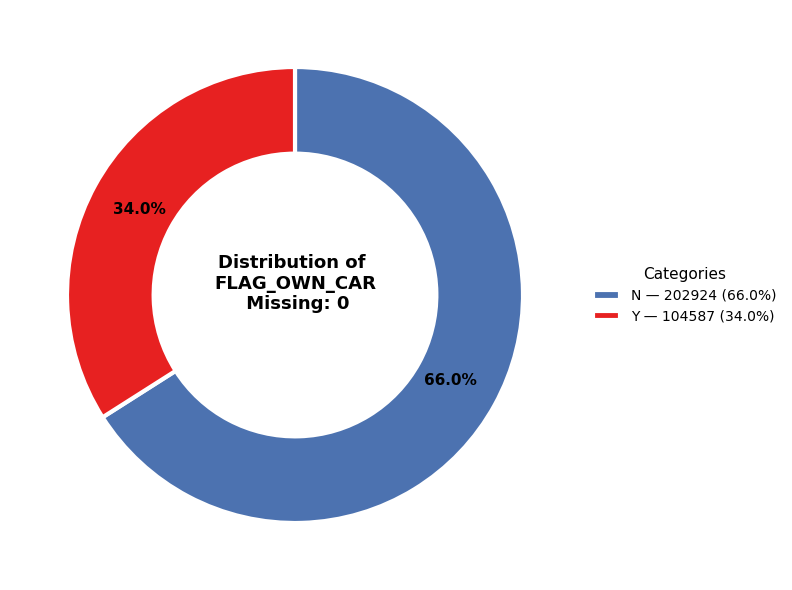

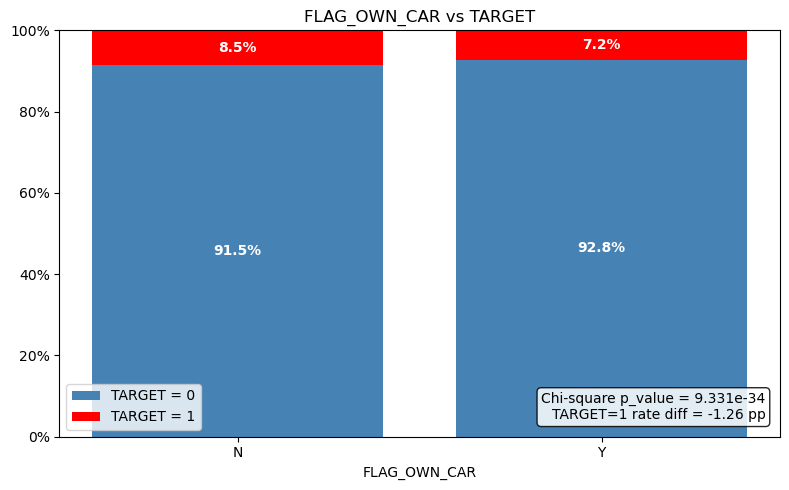

In [3]:
plot_binary_distribution(df=app_df, binary_var='FLAG_OWN_CAR')
plot_binary_vs_binary(df=app_df, binary_var='FLAG_OWN_CAR', target_var='TARGET')

There is a small difference in distributions

## 2. FLAG_OWN_REALTY
Flag if client owns a house or flat

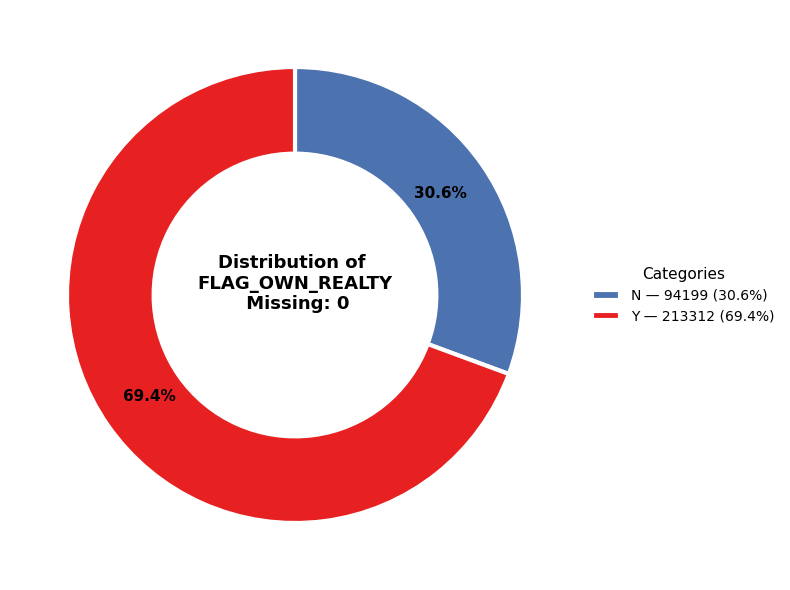

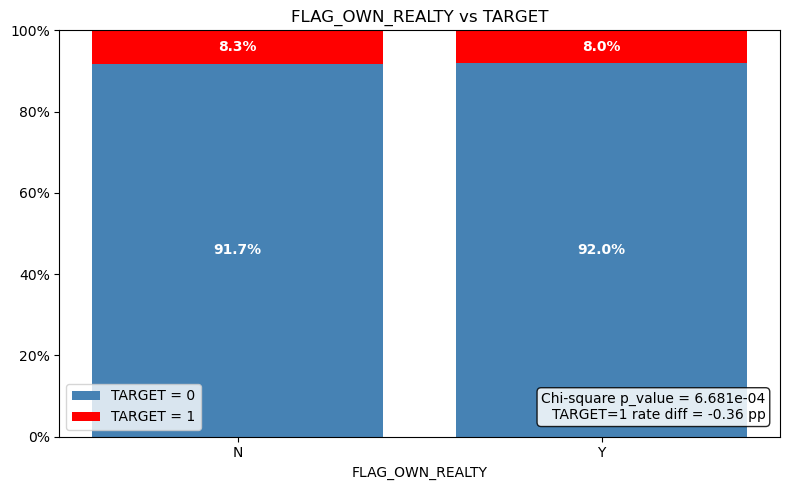

In [4]:
plot_binary_distribution(df=app_df, binary_var='FLAG_OWN_REALTY')
plot_binary_vs_binary(df=app_df, binary_var='FLAG_OWN_REALTY', target_var='TARGET')

## 3. AMT_INCOME_TOTAL
Income of the client

In [5]:
app_df['AMT_INCOME_TOTAL'].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

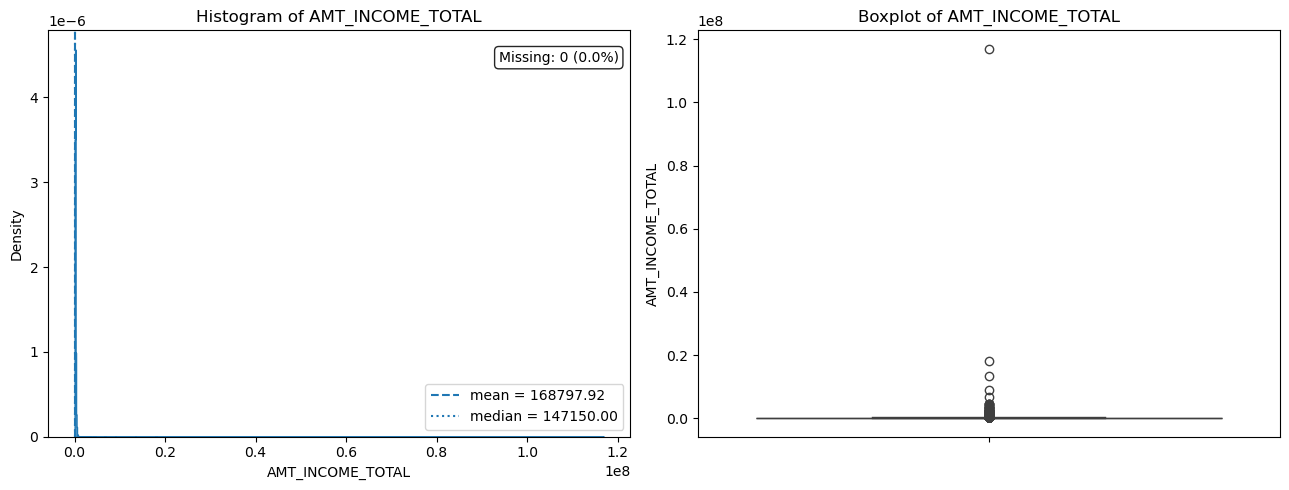

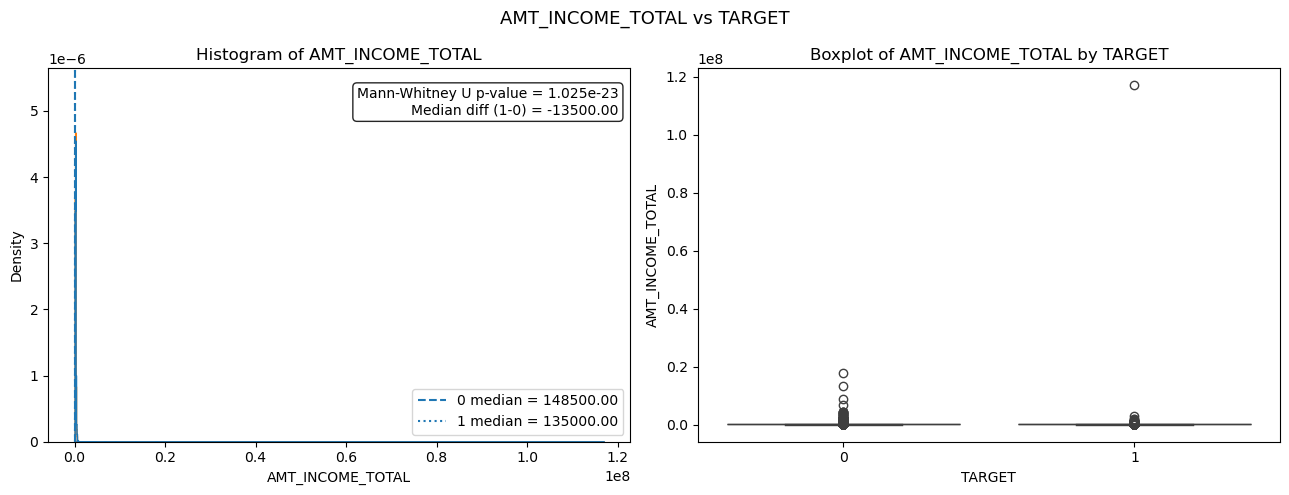

In [6]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_INCOME_TOTAL')
plot_quantitative_vs_binary(df=app_df, quant_var='AMT_INCOME_TOTAL', binary_var='TARGET')

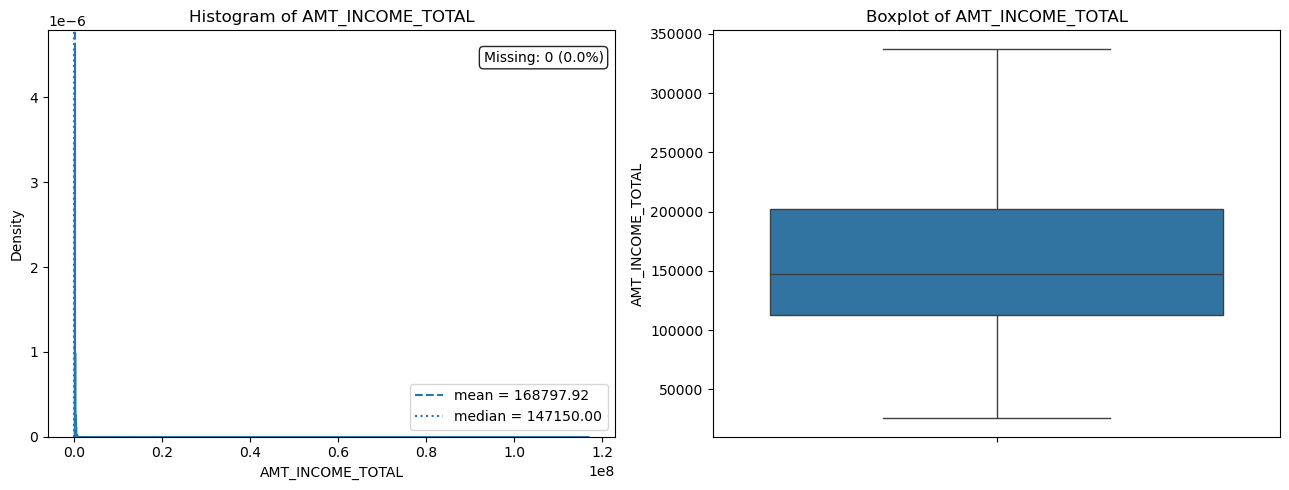

In [7]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_INCOME_TOTAL', show_outliers=False)

In [8]:
max_income = app_df['AMT_INCOME_TOTAL'].max()
print(f"Max income: {max_income}")
app_df[app_df['AMT_INCOME_TOTAL'] == max_income]

Max income: 117000000.0


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
12840,114967,1,Cash loans,F,N,Y,1,117000000.0,562491.0,26194.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0


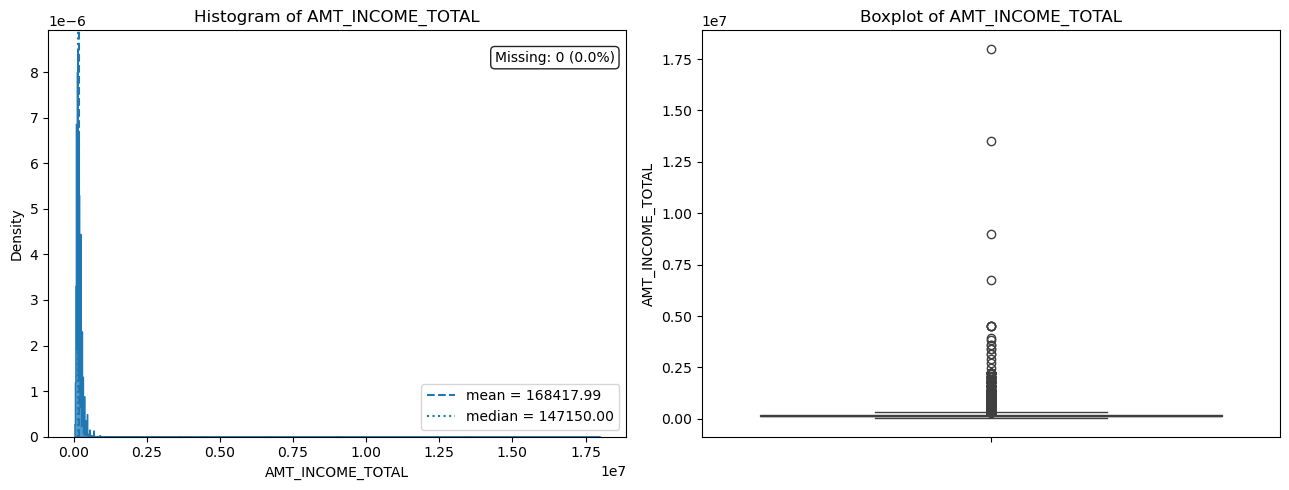

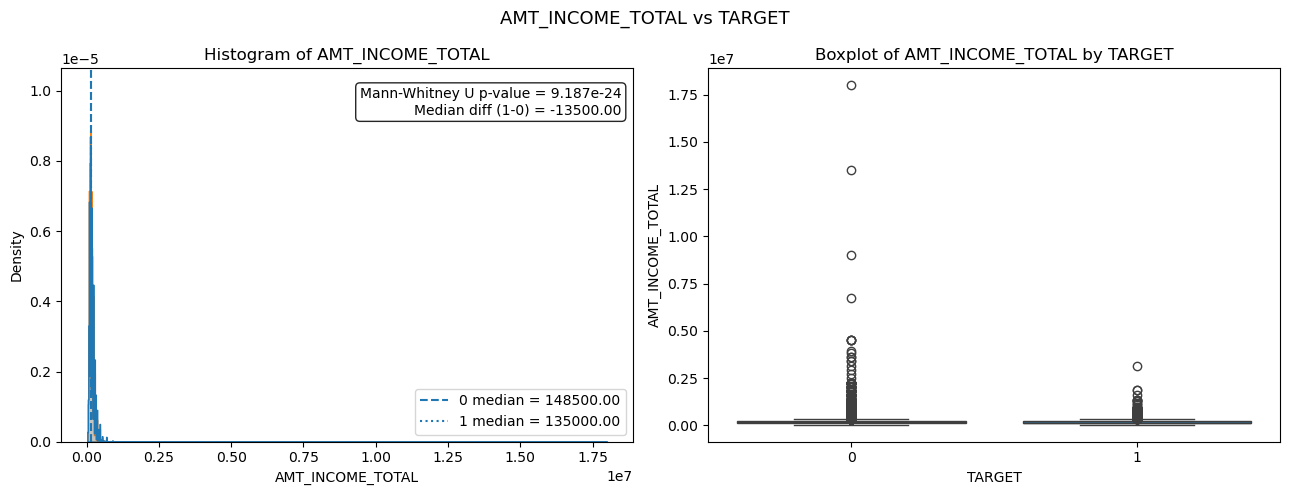

In [9]:
plot_quantitative_distribution(
    df=app_df[app_df['AMT_INCOME_TOTAL'] != max_income], 
    quant_var='AMT_INCOME_TOTAL'
)
plot_quantitative_vs_binary(
    df=app_df[app_df['AMT_INCOME_TOTAL'] != max_income], 
    quant_var='AMT_INCOME_TOTAL', 
    binary_var='TARGET'
)

In [10]:
print(len(app_df))

307511


In [11]:
trimmed_income, df_income_trimmed, income_trimming_summary, = trim_quantitative_var(
    df = app_df, 
    quant_var='AMT_INCOME_TOTAL',
    lower = 0.0,
    upper = 0.975,
    return_trimmed_df = True,
    return_summary = True
)

income_trimming_summary

quant_var               AMT_INCOME_TOTAL
lower_quantile                       0.0
upper_quantile                     0.975
lower_bound                      25650.0
upper_bound                     405000.0
n_rows_before                     307511
n_rows_after                      301164
n_rows_dropped                      6347
rows_dropped_share               0.02064
n_dropped_from_lower                   0
n_dropped_from_upper                6347
n_missing_in_var                       0
dtype: object

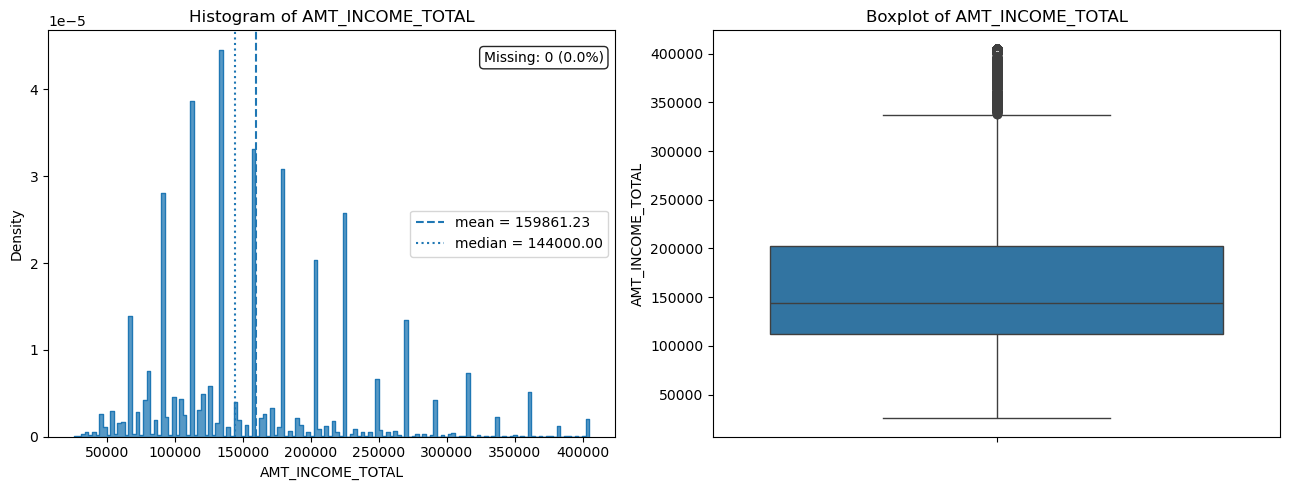

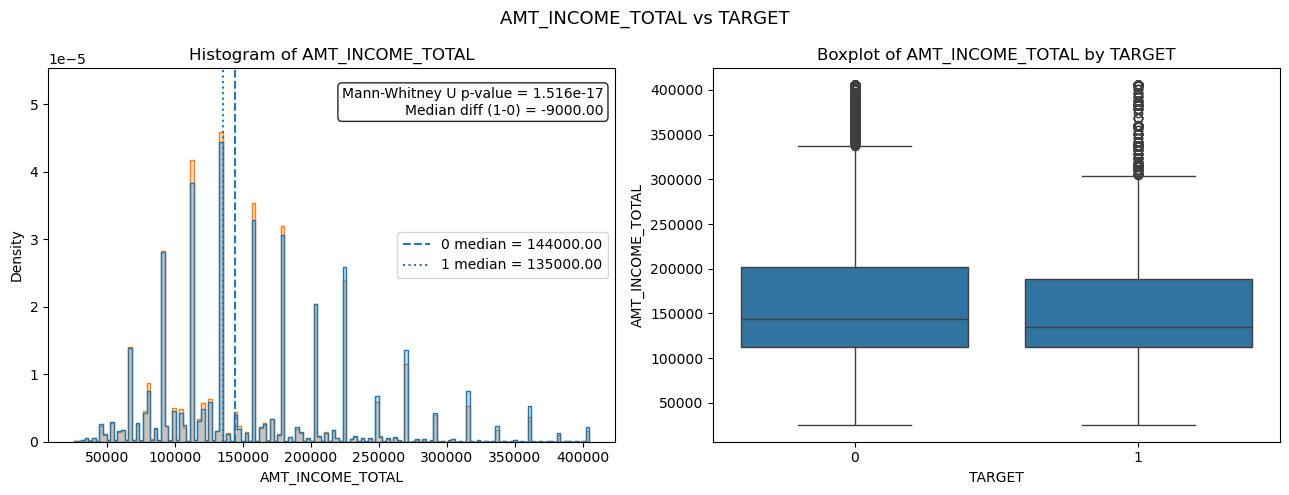

In [12]:
plot_quantitative_distribution(
    df = df_income_trimmed, 
    quant_var='AMT_INCOME_TOTAL'
)
plot_quantitative_vs_binary(
    df = df_income_trimmed,
    quant_var='AMT_INCOME_TOTAL', 
    binary_var='TARGET'
)

After trimming off outliers we can see that distribution is different with respect to target values. Clients who defaulted have statistically lower income.
The next thing is to created capped variable in order not to loose information from observation with income values that are outliers.

In [13]:
capped_df, summary = cap_quantitative_var(
    app_df,
    quant_var='AMT_INCOME_TOTAL',
    cap_quantile=0.9,
    return_capped_var=False,
    return_capped_df=True,
    return_summary=True
)

summary

quant_var                                   AMT_INCOME_TOTAL
capped_col                       AMT_INCOME_TOTAL_capped_0_9
cap_quantile                                             0.9
upper_bound                                         270000.0
n_rows_total                                          307511
n_non_missing                                         307511
n_missing_in_var                                           0
n_rows_capped                                          27161
rows_capped_share_total                             0.088325
rows_capped_share_non_missing                       0.088325
dtype: object

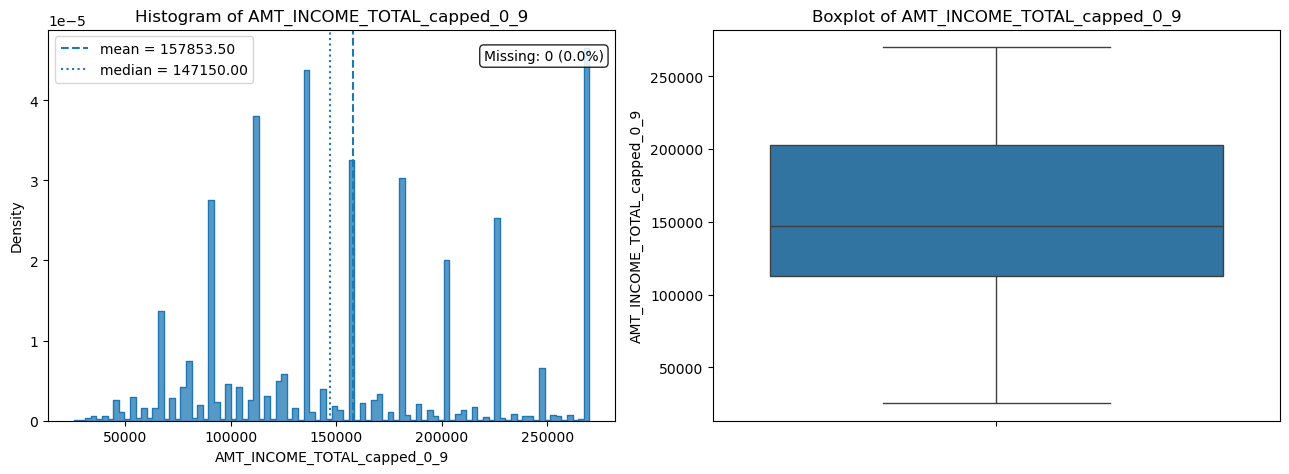

TypeError: plot_quantitative_distribution() got an unexpected keyword argument 'binary_var'

In [ ]:
plot_quantitative_distribution(
    df=capped_df,
    quant_var='AMT_INCOME_TOTAL_capped_0_9'
)
plot_quantitative_vs_binary(
    df=capped_df,
    quant_var='AMT_INCOME_TOTAL_capped_0_9',
    binary_var = 'TARGET'
)

## 4. NAME_INCOME_TYPE
Clients income type (businessman, working, maternity leave,…)

In [ ]:
app_df['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

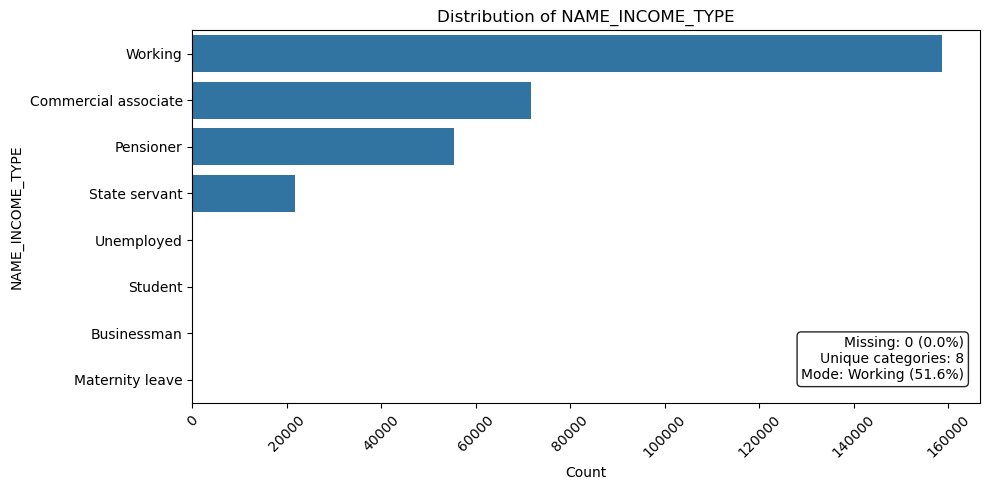

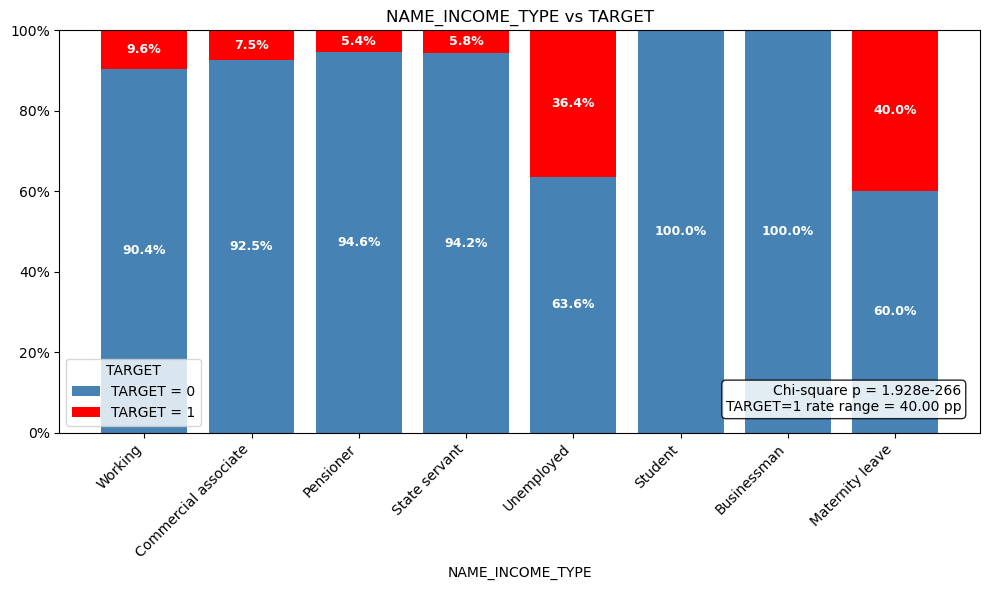

In [ ]:
plot_categorical_distribution(df=app_df, cat_var='NAME_INCOME_TYPE')
plot_categorical_vs_binary(df=app_df, cat_var='NAME_INCOME_TYPE', target_var='TARGET')

Categories `Unemployed`, `Student`, `Businessman`, and `Maternity leave` will be grouped together because there are extremely underrepreseted in the data and even if they have quite big share of `Target = 1` it is probably not stable signal. 

In [15]:
app_df['NAME_INCOME_TYPE_grouped'] = np.where(
    app_df['NAME_INCOME_TYPE'].isin(values=['Unemployed', 'Student', 'Businessman', 'Maternity leave']),
    'other',
    app_df['NAME_INCOME_TYPE']
)

app_df['NAME_INCOME_TYPE_grouped'].value_counts()

NAME_INCOME_TYPE_grouped
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
other                       55
Name: count, dtype: int64

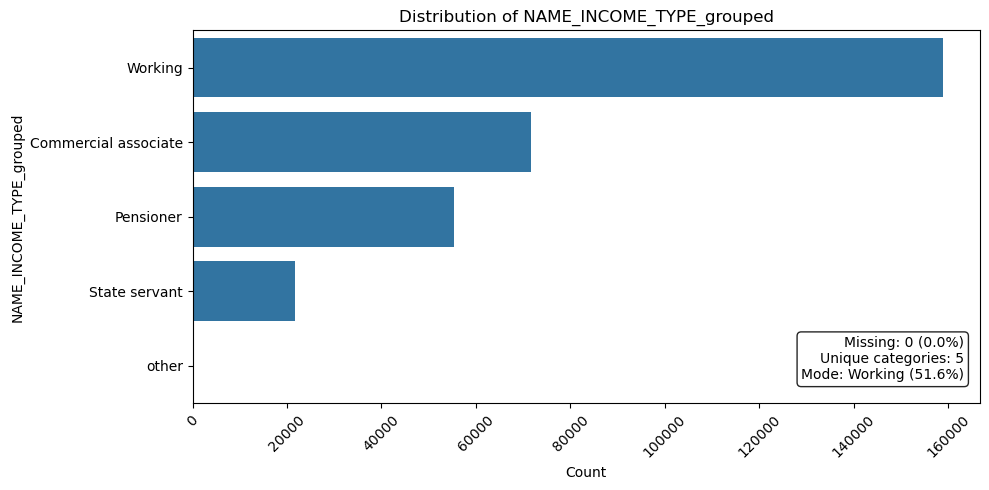

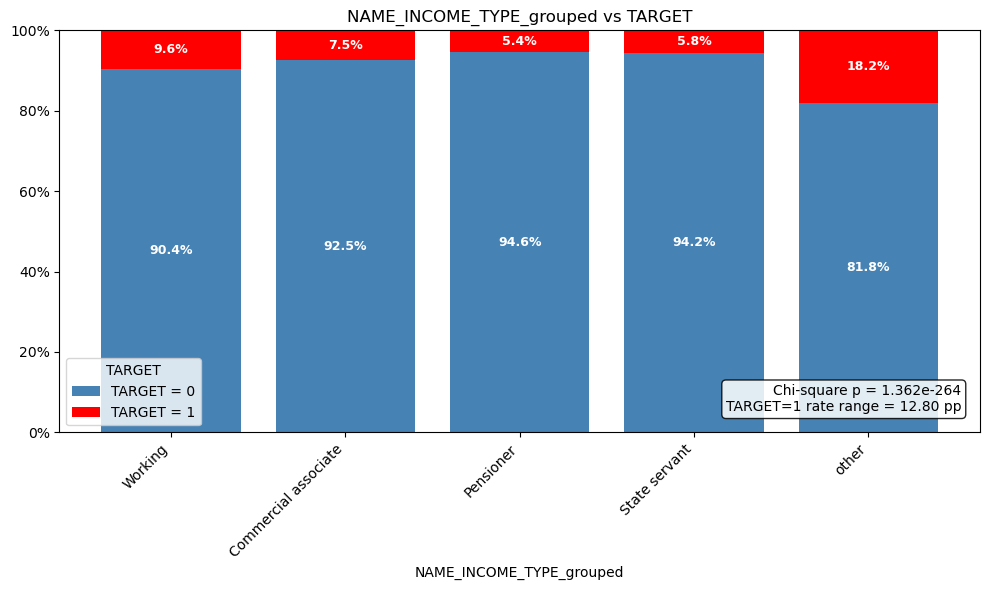

In [16]:
plot_categorical_distribution(df=app_df, cat_var='NAME_INCOME_TYPE_grouped')
plot_categorical_vs_binary(df=app_df, cat_var='NAME_INCOME_TYPE_grouped', target_var='TARGET')

The bucket `other' is still extremely small and probably statistically meaningless category so it should be merged with other category or entirely dropped.

Approach:
- Maternity leave, Student, Unemployed -> Pensioner 
- Businessman -> Working

In [17]:
app_df['NAME_INCOME_TYPE_grouped'] = np.where(
    app_df['NAME_INCOME_TYPE'].isin(values=['Pensioner', 'Unemployed', 'Student', 'Maternity leave']),
    'Pensioner',
    np.where(
        app_df['NAME_INCOME_TYPE'].isin(['Working', 'Businessman']),
        'Working',
        app_df['NAME_INCOME_TYPE']
    )
)

app_df['NAME_INCOME_TYPE_grouped'].value_counts()

NAME_INCOME_TYPE_grouped
Working                 158784
Commercial associate     71617
Pensioner                55407
State servant            21703
Name: count, dtype: int64

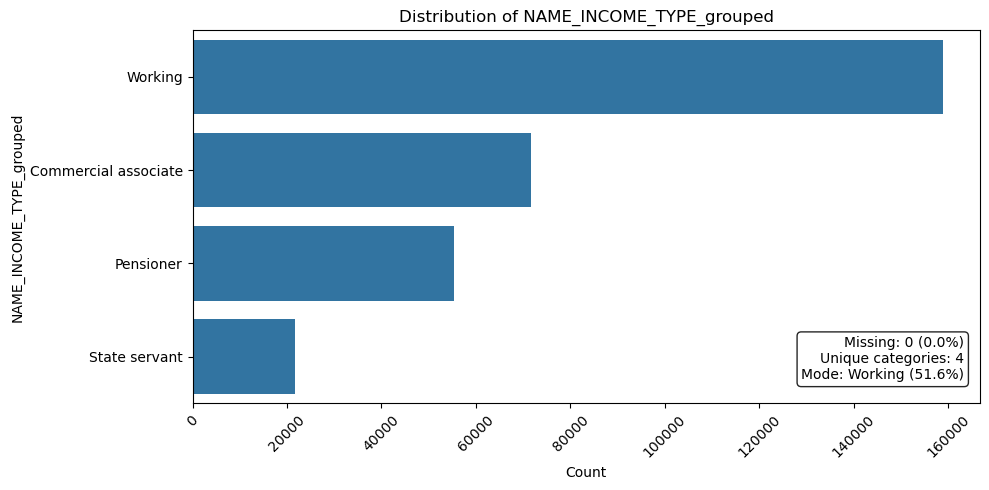

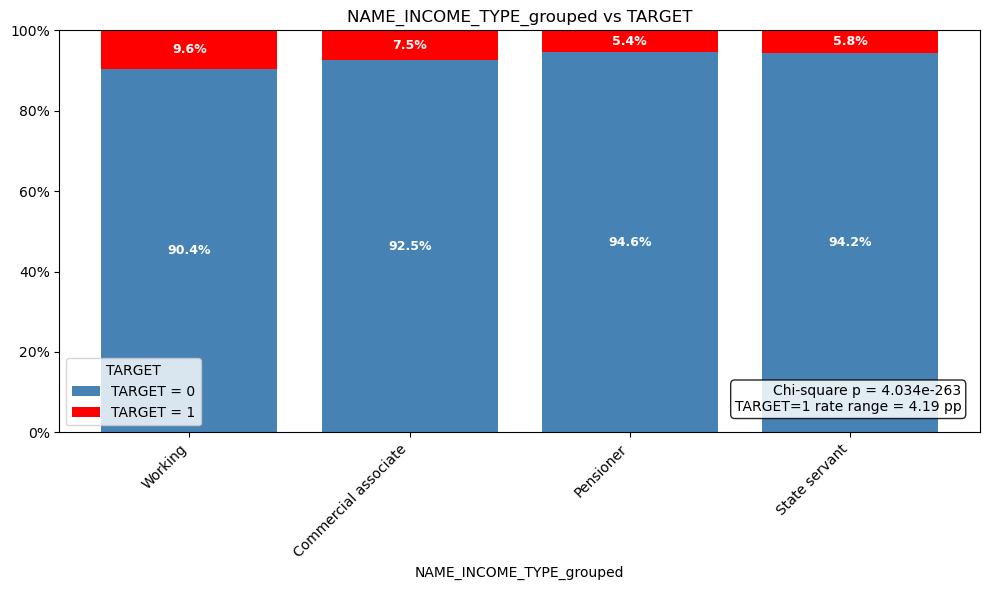

In [18]:
plot_categorical_distribution(df=app_df, cat_var='NAME_INCOME_TYPE_grouped')
plot_categorical_vs_binary(df=app_df, cat_var='NAME_INCOME_TYPE_grouped', target_var='TARGET')

`TARGET = 1` share sigificantly differs across categories, so probably `NAME_INCOME_TYPE_grouped` will be a good predictor.

## 5. NAME_HOUSING_TYPE
What is the housing situation of the client (renting, living with parents, ...)

In [19]:
app_df['NAME_HOUSING_TYPE'].value_counts()

NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64

In [23]:
app_df[['NAME_HOUSING_TYPE','TARGET']].groupby('TARGET').value_counts()

TARGET  NAME_HOUSING_TYPE  
0       House / apartment      251596
        With parents            13104
        Municipal apartment     10228
        Rented apartment         4280
        Office apartment         2445
        Co-op apartment          1033
1       House / apartment       21272
        With parents             1736
        Municipal apartment       955
        Rented apartment          601
        Office apartment          172
        Co-op apartment            89
Name: count, dtype: int64

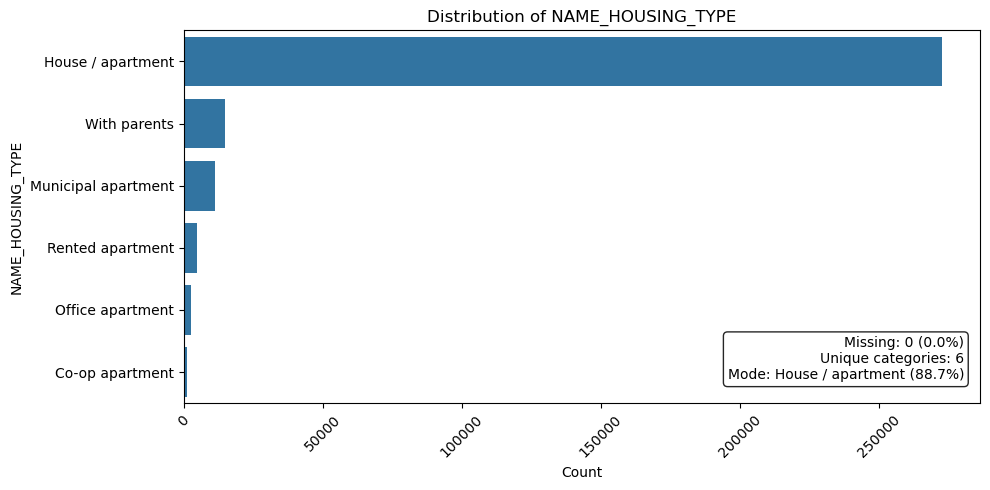

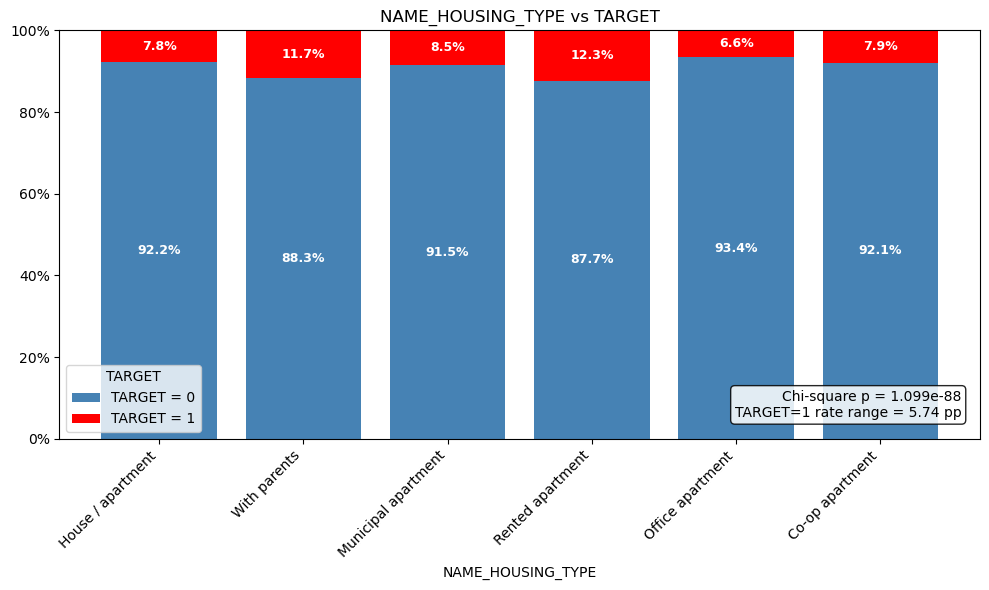

In [ ]:
plot_categorical_distribution(df=app_df, cat_var='NAME_HOUSING_TYPE')
plot_categorical_vs_binary(df=app_df, cat_var='NAME_HOUSING_TYPE', target_var='TARGET')

There is no extremely low category and `TARGET = 1` share differes accros categories so the variable will be grouped according to risk level.

In [24]:
app_df['NAME_HOUSING_TYPE_grouped'] = np.where(
    app_df['NAME_HOUSING_TYPE'].isin(['With parents', 'Rented apartment']),
    'With parents / Rented apartment',
    np.where(
        app_df['NAME_HOUSING_TYPE'].isin(['Municipal apartment', 'Office apartment', 'Co-op apartment']),
        'Municipal / Office / Co-op apartment',
        app_df['NAME_HOUSING_TYPE']
    )
)

app_df['NAME_HOUSING_TYPE_grouped'].value_counts()

NAME_HOUSING_TYPE_grouped
House / apartment                       272868
With parents / Rented apartment          19721
Municipal / Office / Co-op apartment     14922
Name: count, dtype: int64

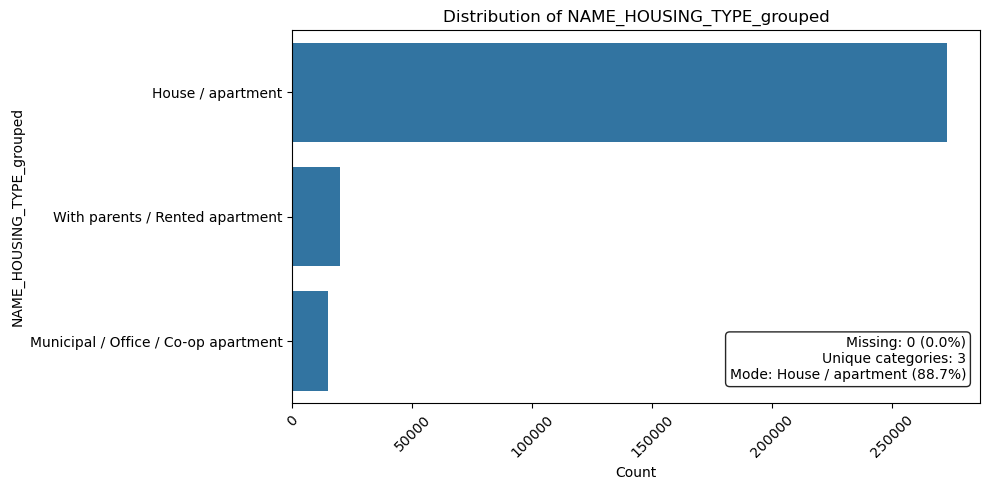

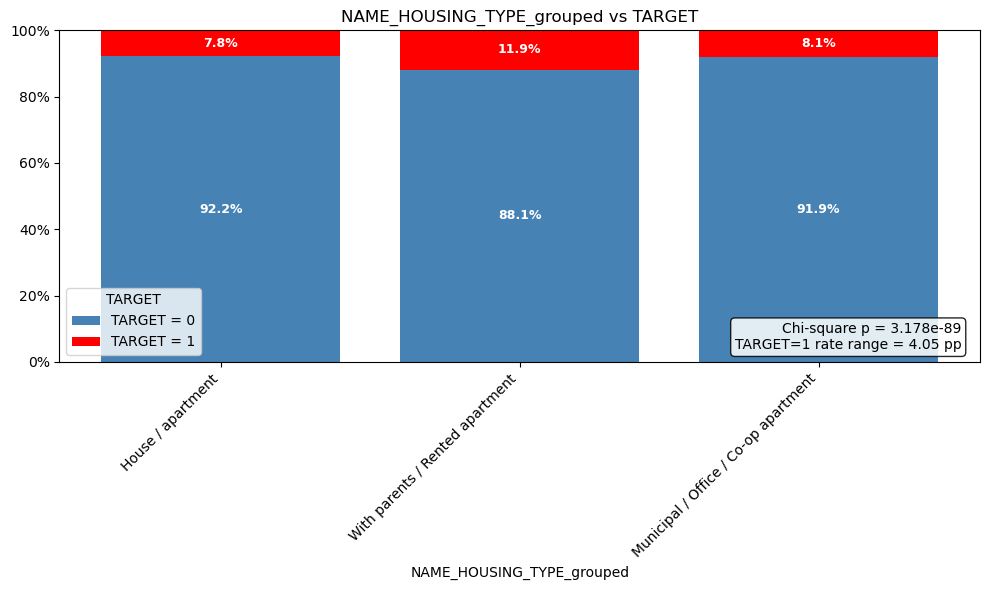

In [25]:
plot_categorical_distribution(df=app_df, cat_var='NAME_HOUSING_TYPE_grouped')
plot_categorical_vs_binary(df=app_df, cat_var='NAME_HOUSING_TYPE_grouped', target_var='TARGET')

## 6. OWN_CAR_AGE
Age of client's car

In [26]:
print(app_df['OWN_CAR_AGE'].isna().sum())
print(app_df['OWN_CAR_AGE'].describe())

202929
count    104582.000000
mean         12.061091
std          11.944812
min           0.000000
25%           5.000000
50%           9.000000
75%          15.000000
max          91.000000
Name: OWN_CAR_AGE, dtype: float64


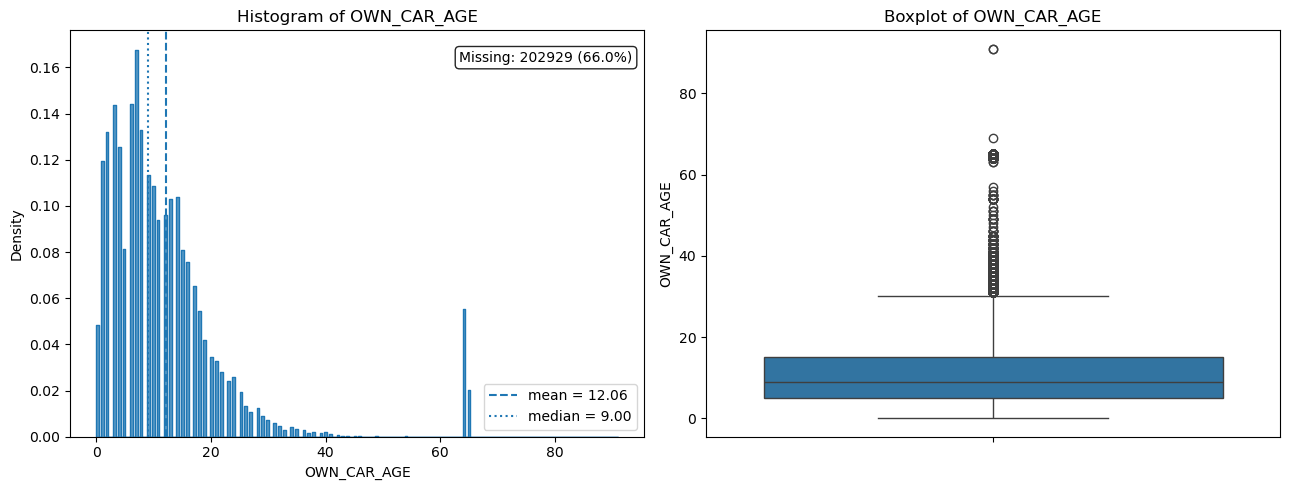

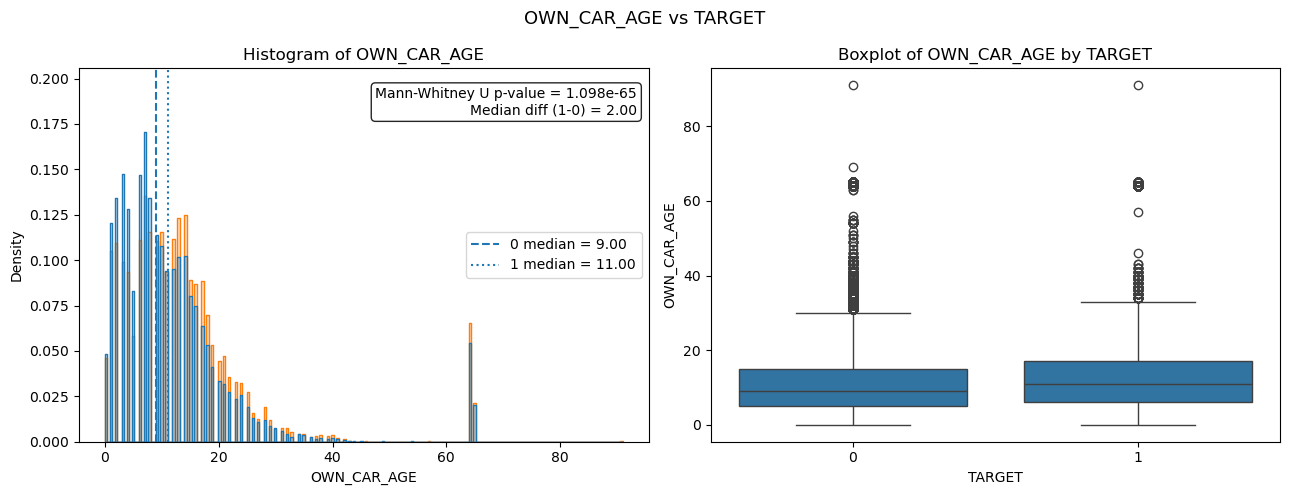

In [ ]:
plot_quantitative_distribution(df=app_df, quant_var='OWN_CAR_AGE')
plot_quantitative_vs_binary(df=app_df, quant_var='OWN_CAR_AGE', binary_var='TARGET')

There are 66 % missing observations so it is above the treshold. Missing flag should be created and used in modeling.

In [27]:
app_df['OWN_CAR_AGE_missing'] = np.where(
    app_df['OWN_CAR_AGE'].isna(),
    1,
    0
)

app_df['OWN_CAR_AGE_missing'].value_counts()

OWN_CAR_AGE_missing
1    202929
0    104582
Name: count, dtype: int64

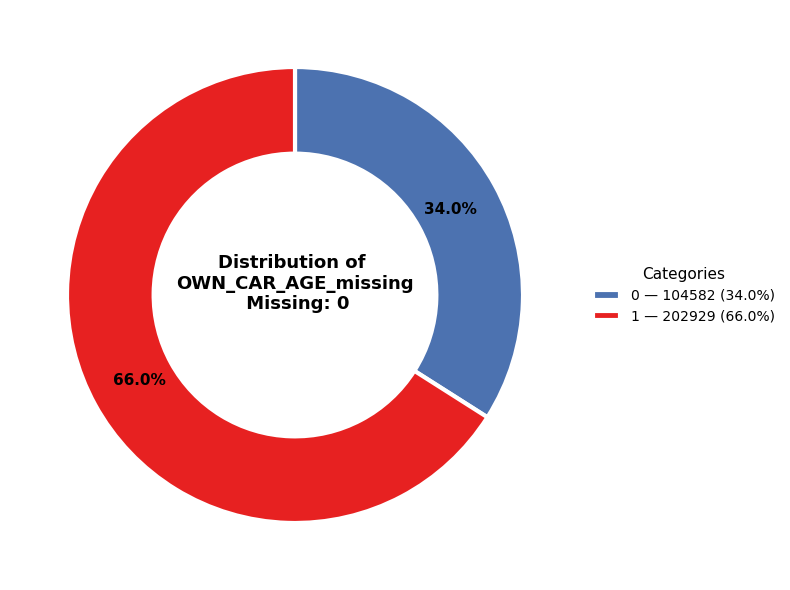

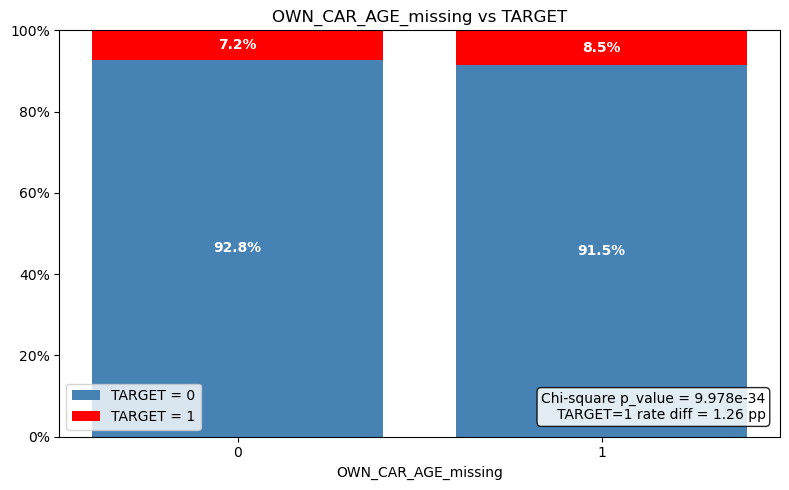

In [28]:
plot_binary_distribution(df=app_df, binary_var='OWN_CAR_AGE_missing')
plot_binary_vs_binary(df=app_df, binary_var='OWN_CAR_AGE_missing', target_var='TARGET')

## 7. Application financial and material summary
Variables that should be used as predictors
- FLAG_OWN_CAR
- NAME_INCOME_TYPE_capped
- NAME_INCOME_TYPE_grouped
- NAME_HOUSING_TYPE_grouped
- OWN_CAR_AGE_missing